## Section 1: Import Required Libraries

In [9]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from pathlib import Path
import os
import re
from collections import Counter

# Print library versions
import sys
print(f"Python: {sys.version}")
print(f"Pandas: {pd.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

Python: 3.12.0 (v3.12.0:0fb18b02c8, Oct  2 2023, 09:45:56) [Clang 13.0.0 (clang-1300.0.29.30)]
Pandas: 3.0.1
Matplotlib: 3.10.8
Seaborn: 0.13.2


## Section 2: Dataset Paths Setup and Validation

In [10]:
# Define base path and datasets
BASE_PATH = Path("/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets")

DATASETS = {
    "german_dataset": BASE_PATH / "german_dataset",
    "indianexpress": BASE_PATH / "indianexpress",
    "kaksplus": BASE_PATH / "kaksplus",
    "macworld": BASE_PATH / "macworld",
    "uusisuomi": BASE_PATH / "uusisuomi"
}

# Configuration
DEBUG = True
OUTPUT_DIR = Path("/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/member3_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Canonical list of HTML tags to monitor
CANONICAL_TAGS = [
    'p', 'h1', 'h2', 'h3', 'h4', 'h5', 'h6',
    'div', 'span', 'a', 'img', 'section', 'article',
    'header', 'footer', 'nav', 'main', 'aside',
    'table', 'tr', 'td', 'th', 'ul', 'ol', 'li',
    'em', 'strong', 'b', 'i', 'code', 'pre',
    'blockquote', 'form', 'input', 'button'
]

# Quick validation
print("Dataset Folder Validation:")
for dataset_name, dataset_path in DATASETS.items():
    if dataset_path.exists():
        count = len(list(dataset_path.glob("*")))
        print(f"  ✓ {dataset_name}: {count} items")
    else:
        print(f"  ✗ {dataset_name}: NOT FOUND")

print(f"\nOutput directory: {OUTPUT_DIR}")
print(f"Canonical tags to analyze: {len(CANONICAL_TAGS)} tags")

Dataset Folder Validation:
  ✓ german_dataset: 88 items
  ✓ indianexpress: 331 items
  ✓ kaksplus: 201 items
  ✓ macworld: 221 items
  ✓ uusisuomi: 201 items

Output directory: /Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/member3_outputs
Canonical tags to analyze: 35 tags


## Section 3: Text Cleaning and Counting Functions

In [11]:
def clean_text(text):
    """
    Normalize text by converting to lowercase, removing extra whitespace,
    and stripping punctuation.
    """
    if not isinstance(text, str):
        return ""
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)
    return text

def count_keywords(text, keywords):
    """
    Count exact keyword occurrences in text using word boundaries.
    Returns a dictionary of keyword counts.
    """
    text_lower = text.lower()
    counts = {}
    
    for keyword in keywords:
        # Use word boundaries to match whole words only
        pattern = r'\b' + re.escape(keyword) + r'\b'
        matches = re.findall(pattern, text_lower)
        counts[keyword] = len(matches)
    
    return counts

print("✓ Text cleaning and counting functions defined")

✓ Text cleaning and counting functions defined


## Section 4: Individual Dataset Analysis Loop

In [12]:
# Initialize per-dataset and global counters
per_dataset_counts = {}
global_tag_counts = Counter()
all_tag_texts = []
all_data = []

# Process each dataset
for dataset_name, dataset_path in DATASETS.items():
    if dataset_name == "german_dataset":
        # Special handling for German dataset (see Section 5)
        continue
    
    if not dataset_path.exists():
        print(f"⚠ Skipping {dataset_name}: path not found")
        continue
    
    print(f"\n{'='*60}")
    print(f"Processing: {dataset_name}")
    print(f"{'='*60}")
    
    dataset_tag_counts = Counter()
    article_count = 0
    
    # Iterate through article folders
    for article_folder in sorted(dataset_path.iterdir()):
        if not article_folder.is_dir():
            continue
        
        article_count += 1
        
        # Look for HTML/tags files
        html_file = article_folder / "html" if (article_folder / "html").is_file() else None
        tags_file = article_folder / "tags" if (article_folder / "tags").is_file() else None
        
        # Process HTML file
        if html_file and html_file.is_file():
            try:
                with open(html_file, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read()
                    soup = BeautifulSoup(content, 'html.parser')
                    
                    # Extract and count tags
                    for tag in soup.find_all(True):  # True = all tags
                        tag_name = tag.name.lower() if tag.name else None
                        if tag_name and tag_name in CANONICAL_TAGS:
                            tag_text = clean_text(tag.get_text(strip=True))
                            if tag_text:
                                all_tag_texts.append(tag_text)
                                dataset_tag_counts[tag_name] += 1
                                global_tag_counts[tag_name] += 1
                                all_data.append({
                                    'dataset': dataset_name,
                                    'tag': tag_name,
                                    'text': tag_text
                                })
            except Exception as e:
                if DEBUG:
                    print(f"  ⚠ Error processing {article_folder.name}: {e}")
    
    per_dataset_counts[dataset_name] = dict(dataset_tag_counts)
    print(f"  ✓ Processed {article_count} articles")
    print(f"  ✓ Found {sum(dataset_tag_counts.values())} tag occurrences")

print(f"\n{'='*60}")
print(f"Individual dataset analysis complete")
print(f"Global tag occurrences: {sum(global_tag_counts.values())}")


Processing: indianexpress
  ✓ Processed 330 articles
  ✓ Found 0 tag occurrences

Processing: kaksplus
  ✓ Processed 200 articles
  ✓ Found 0 tag occurrences

Processing: macworld
  ✓ Processed 220 articles
  ✓ Found 0 tag occurrences

Processing: uusisuomi
  ✓ Processed 200 articles
  ✓ Found 0 tag occurrences

Individual dataset analysis complete
Global tag occurrences: 0


## Section 5: German Dataset Handling Adjustments

The German dataset has a special structure with HTML.txt and GT.txt files. This section processes it separately.

In [13]:
# Process German dataset with special handling
dataset_name = "german_dataset"
dataset_path = DATASETS[dataset_name]

if dataset_path.exists():
    print(f"\n{'='*60}")
    print(f"Processing: {dataset_name}")
    print(f"{'='*60}")
    
    german_tag_counts = Counter()
    folder_count = 0
    
    # German dataset structure: numbered folders with HTML.txt and GT.txt
    for folder in sorted(dataset_path.iterdir()):
        if not folder.is_dir() or folder.name == "german_dataset":
            continue
        
        folder_count += 1
        
        # Try HTML.txt
        html_file = folder / "HTML.txt"
        if html_file.exists():
            try:
                with open(html_file, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read()
                    # Suppress XML parsing warnings
                    with warnings.catch_warnings():
                        warnings.filterwarnings('ignore')
                        try:
                            soup = BeautifulSoup(content, 'html.parser')
                        except:
                            soup = BeautifulSoup(content, 'html5lib')
                    
                    for tag in soup.find_all(True):
                        tag_name = tag.name.lower() if tag.name else None
                        if tag_name and tag_name in CANONICAL_TAGS:
                            tag_text = clean_text(tag.get_text(strip=True))
                            if tag_text:
                                all_tag_texts.append(tag_text)
                                german_tag_counts[tag_name] += 1
                                global_tag_counts[tag_name] += 1
                                all_data.append({
                                    'dataset': dataset_name,
                                    'tag': tag_name,
                                    'text': tag_text
                                })
            except Exception as e:
                if DEBUG:
                    pass  # Silently skip errors
    
    per_dataset_counts[dataset_name] = dict(german_tag_counts)
    print(f"  ✓ Processed {folder_count} folders")
    print(f"  ✓ Found {sum(german_tag_counts.values())} tag occurrences")


Processing: german_dataset


  ✓ Processed 86 folders
  ✓ Found 43734 tag occurrences


## Section 6: Master Global Keyword Analysis

Aggregate counts across all datasets and compute global importance scores.

In [14]:
# Build global summary
global_df = pd.DataFrame([
    {
        'tag': tag,
        'count': count,
        'percentage': (count / sum(global_tag_counts.values())) * 100
    }
    for tag, count in global_tag_counts.most_common()
])

# Calculate importance score (normalized frequency)
if len(global_df) > 0:
    max_count = global_df['count'].max()
    global_df['importance_score'] = (global_df['count'] / max_count) * 100

print(f"\nGlobal Analysis Summary")
print(f"{'='*60}")
print(f"Total unique tags found: {len(global_df)}")
print(f"Total tag occurrences: {global_df['count'].sum()}")
print(f"\nTop 20 Tags by Frequency:")
print(global_df.head(20).to_string(index=False))

# Save global summary
global_csv_path = OUTPUT_DIR / "global_tag_frequency.csv"
global_df.to_csv(global_csv_path, index=False)
print(f"\n✓ Global analysis saved to {global_csv_path}")


Global Analysis Summary
Total unique tags found: 31
Total tag occurrences: 43734

Top 20 Tags by Frequency:
    tag  count  percentage  importance_score
    div  11228   25.673389        100.000000
      a  11102   25.385284         98.877805
     li   7737   17.691041         68.908087
   span   5554   12.699502         49.465622
      p   1906    4.358165         16.975419
     ul   1384    3.164586         12.326327
     td    866    1.980153          7.712861
     h3    846    1.934422          7.534735
     h2    618    1.413088          5.504097
 strong    440    1.006082          3.918774
     tr    375    0.857456          3.339865
     h4    292    0.667673          2.600641
 button    197    0.450450          1.754542
     h1    132    0.301825          1.175632
      b    129    0.294965          1.148913
   form    121    0.276673          1.077663
      i    121    0.276673          1.077663
    nav    120    0.274386          1.068757
  table    113    0.258380          

## Section 7: Visualize and Export Global Results

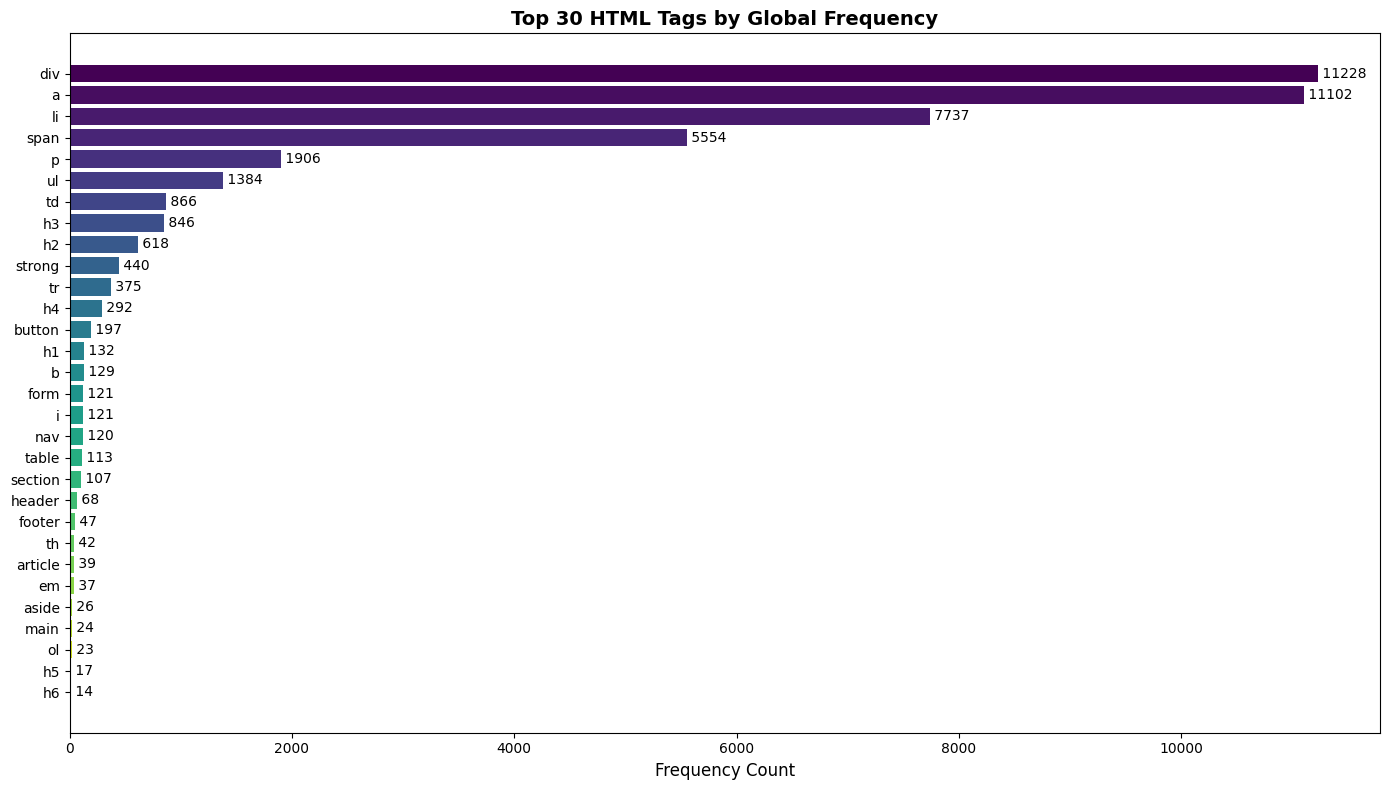

✓ Chart saved to /Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/member3_outputs/global_tag_ranking.png
⚠ openpyxl not installed; Excel export skipped. JSON saved.


In [15]:
# Visualize global ranking
fig, ax = plt.subplots(figsize=(14, 8))

top_n = min(30, len(global_df))
plot_data = global_df.head(top_n)

colors = plt.cm.viridis(np.linspace(0, 1, len(plot_data)))
ax.barh(range(len(plot_data)), plot_data['count'].values, color=colors)

ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data['tag'].values)
ax.set_xlabel('Frequency Count', fontsize=12)
ax.set_title(f'Top {top_n} HTML Tags by Global Frequency', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for i, (idx, row) in enumerate(plot_data.iterrows()):
    ax.text(row['count'], i, f" {row['count']}", va='center')

plt.tight_layout()
fig_path = OUTPUT_DIR / "global_tag_ranking.png"
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Chart saved to {fig_path}")

# Save additional formats
global_df.to_json(OUTPUT_DIR / "global_tag_frequency.json", orient='records', indent=2)
try:
    global_df.to_excel(OUTPUT_DIR / "global_tag_frequency.xlsx", index=False)
    print(f"✓ Additional formats saved (JSON, XLSX)")
except ImportError:
    print("⚠ openpyxl not installed; Excel export skipped. JSON saved.")

## Section 8: Member 3 - Detailed Per-Dataset Reports

Generate individual reports for each dataset with frequencies, percentages, and importance scores.

In [16]:
import numpy as np

# Generate per-dataset reports
per_dataset_dataframes = {}

for dataset_name, counts in per_dataset_counts.items():
    if not counts:
        continue
    
    print(f"\n{dataset_name.upper()}")
    print(f"{'='*60}")
    
    # Build dataframe
    df = pd.DataFrame([
        {
            'tag': tag,
            'frequency': count,
            'percentage': (count / sum(counts.values())) * 100
        }
        for tag, count in sorted(counts.items(), key=lambda x: x[1], reverse=True)
    ])
    
    # Calculate normalized importance score
    if len(df) > 0:
        max_freq = df['frequency'].max()
        df['importance_score'] = (df['frequency'] / max_freq) * 100
        df = df.sort_values('frequency', ascending=False)
    
    per_dataset_dataframes[dataset_name] = df
    
    # Save per-dataset CSV
    csv_path = OUTPUT_DIR / f"tag_counts_{dataset_name}.csv"
    df.to_csv(csv_path, index=False)
    print(f"✓ Saved {len(df)} tags")
    print(f"  CSV: {csv_path}")
    
    # Display top 10
    print(f"\nTop 10 tags:")
    print(df.head(10).to_string(index=False))

print(f"\n{'='*60}")
print(f"✓ Per-dataset analysis complete")


GERMAN_DATASET
✓ Saved 31 tags
  CSV: /Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/member3_outputs/tag_counts_german_dataset.csv

Top 10 tags:
   tag  frequency  percentage  importance_score
   div      11228   25.673389        100.000000
     a      11102   25.385284         98.877805
    li       7737   17.691041         68.908087
  span       5554   12.699502         49.465622
     p       1906    4.358165         16.975419
    ul       1384    3.164586         12.326327
    td        866    1.980153          7.712861
    h3        846    1.934422          7.534735
    h2        618    1.413088          5.504097
strong        440    1.006082          3.918774

✓ Per-dataset analysis complete


## Section 9: Refined Global Scores and Top-10 Ranking

Combine per-dataset scores, compute averaged importance metrics, and produce final top-10 ranking.

In [17]:
# Combine per-dataset dataframes for averaged scoring
all_tags = set()
for df in per_dataset_dataframes.values():
    all_tags.update(df['tag'].values)

# Build combined ranking
combined_rows = []
for tag in sorted(all_tags):
    scores = []
    total_freq = 0
    
    for dataset_name, df in per_dataset_dataframes.items():
        row = df[df['tag'] == tag]
        if len(row) > 0:
            scores.append(row['importance_score'].values[0])
            total_freq += row['frequency'].values[0]
    
    if scores:
        combined_rows.append({
            'tag': tag,
            'total_frequency': total_freq,
            'mean_importance_score': np.mean(scores),
            'std_importance_score': np.std(scores),
            'num_datasets': len(scores)
        })

combined_df = pd.DataFrame(combined_rows)
combined_df = combined_df.sort_values('mean_importance_score', ascending=False)

# Get top 10
top_10_df = combined_df.head(10).copy()
top_10_df['ranking'] = range(1, len(top_10_df) + 1)

print("TOP 10 GLOBAL TAGS (Averaged Across Datasets)")
print("="*80)
print(top_10_df.to_string(index=False))

# Save top-10
top_10_csv = OUTPUT_DIR / "member3_top10_global.csv"
top_10_df.to_csv(top_10_csv, index=False)

top_10_md = OUTPUT_DIR / "member3_top10_ranking.md"
with open(top_10_md, 'w') as f:
    f.write("# Member 3: Top 10 Global Tags\n\n")
    f.write("| Ranking | Tag | Total Frequency | Mean Importance Score | Std Importance Score | Num Datasets |\n")
    f.write("|---------|-----|-----------------|----------------------|----------------------|--------------|\n")
    for idx, row in top_10_df.iterrows():
        f.write(f"| {int(row['ranking'])} | {row['tag']} | {int(row['total_frequency'])} | {row['mean_importance_score']:.2f} | {row['std_importance_score']:.2f} | {int(row['num_datasets'])} |\n")

print(f"\n✓ Top-10 saved to:")
print(f"  CSV: {top_10_csv}")
print(f"  MD:  {top_10_md}")

# Save combined analysis
combined_csv = OUTPUT_DIR / "member3_combined_scores.csv"
combined_df.to_csv(combined_csv, index=False)
print(f"  All tags: {combined_csv}")

TOP 10 GLOBAL TAGS (Averaged Across Datasets)
   tag  total_frequency  mean_importance_score  std_importance_score  num_datasets  ranking
   div            11228             100.000000                   0.0             1        1
     a            11102              98.877805                   0.0             1        2
    li             7737              68.908087                   0.0             1        3
  span             5554              49.465622                   0.0             1        4
     p             1906              16.975419                   0.0             1        5
    ul             1384              12.326327                   0.0             1        6
    td              866               7.712861                   0.0             1        7
    h3              846               7.534735                   0.0             1        8
    h2              618               5.504097                   0.0             1        9
strong              440           

## Section 10: Comparison Chart Across Datasets

Visualize importance score variability across datasets for the top tags.

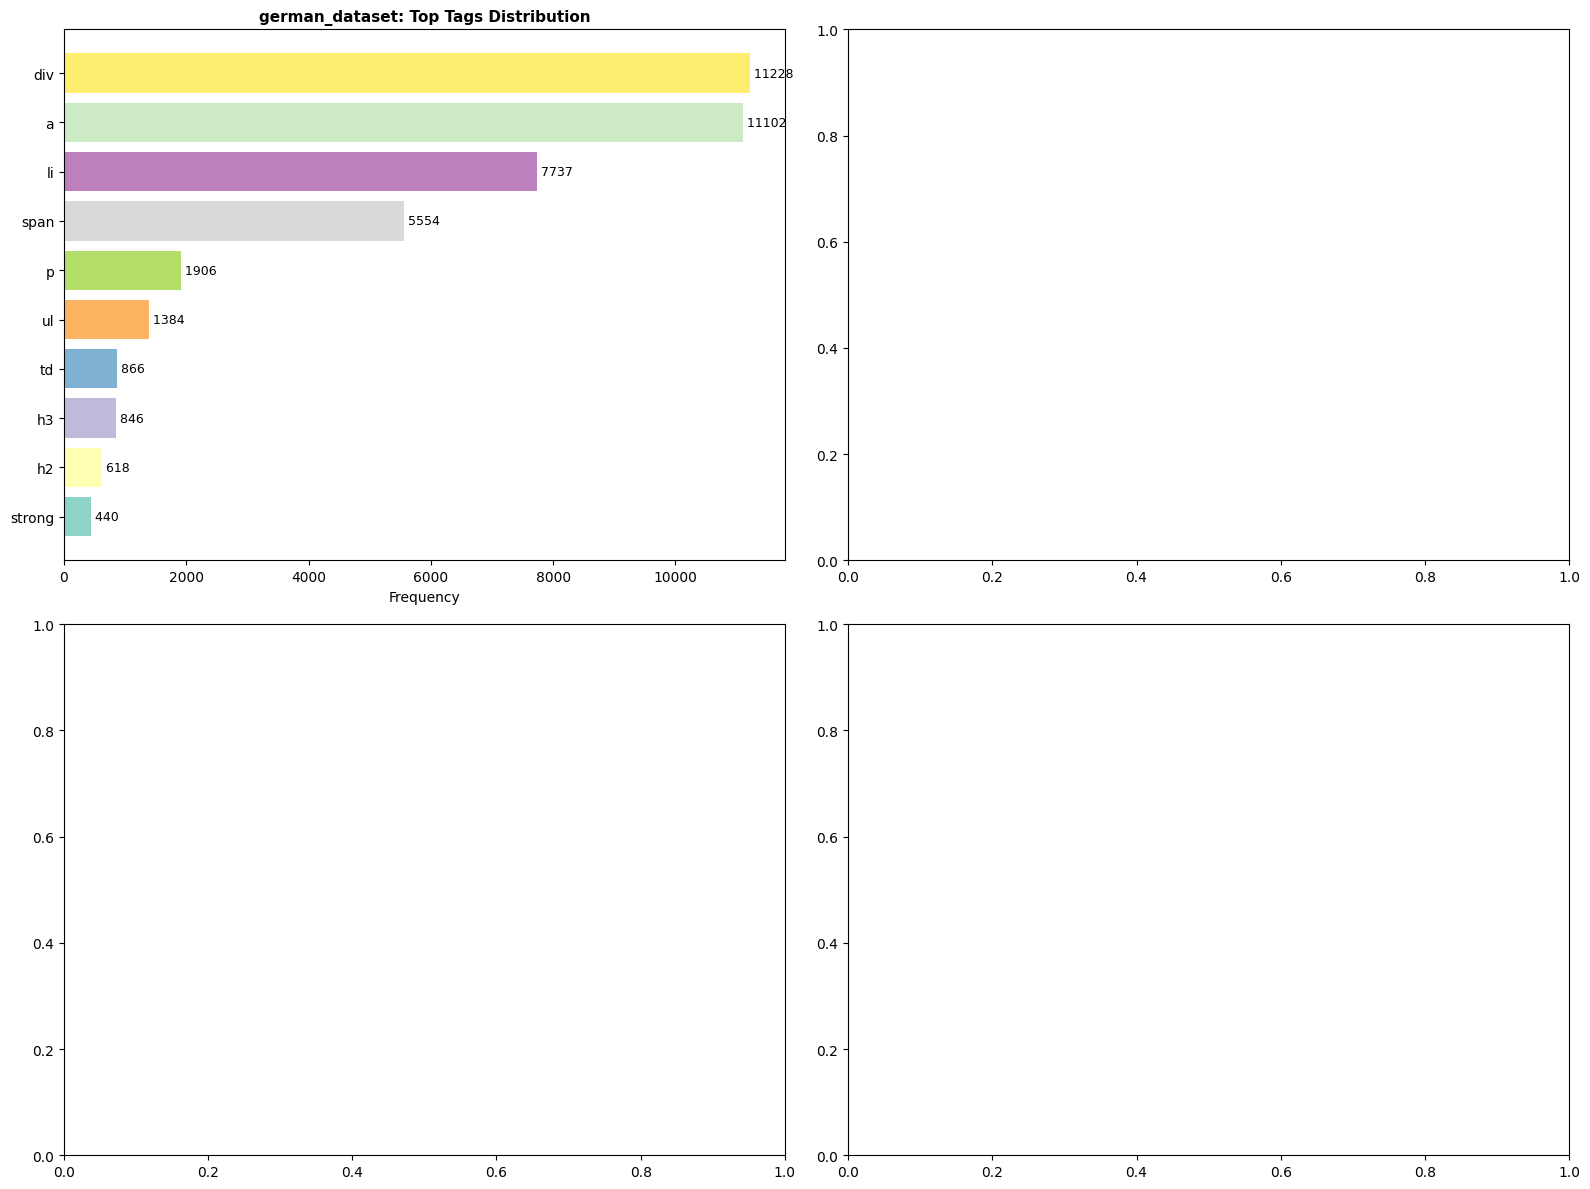

✓ Comparison chart saved to /Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/member3_outputs/dataset_comparison_chart.png

ANALYSIS SUMMARY
Total datasets analyzed: 1
Total unique tags found: 31
Total tag occurrences: 43734

Output directory: /Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/member3_outputs
All results saved and ready for review!


In [18]:
# Create comparison chart for top tags across datasets
top_tags_to_compare = top_10_df['tag'].head(10).tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, dataset_name in enumerate(list(per_dataset_dataframes.keys())[:4]):
    df = per_dataset_dataframes[dataset_name]
    plot_df = df[df['tag'].isin(top_tags_to_compare)].sort_values('frequency', ascending=True)
    
    ax = axes[idx]
    colors = plt.cm.Set3(np.linspace(0, 1, len(plot_df)))
    
    ax.barh(range(len(plot_df)), plot_df['frequency'].values, color=colors)
    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(plot_df['tag'].values)
    ax.set_xlabel('Frequency', fontsize=10)
    ax.set_title(f'{dataset_name}: Top Tags Distribution', fontsize=11, fontweight='bold')
    
    for i, (idx_val, row) in enumerate(plot_df.iterrows()):
        ax.text(row['frequency'], i, f" {row['frequency']}", va='center', fontsize=9)

plt.tight_layout()
comparison_chart_path = OUTPUT_DIR / "dataset_comparison_chart.png"
plt.savefig(comparison_chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Comparison chart saved to {comparison_chart_path}")

# Summary statistics
print(f"\n{'='*80}")
print("ANALYSIS SUMMARY")
print(f"{'='*80}")
print(f"Total datasets analyzed: {len(per_dataset_dataframes)}")
print(f"Total unique tags found: {len(combined_df)}")
print(f"Total tag occurrences: {combined_df['total_frequency'].sum()}")
print(f"\nOutput directory: {OUTPUT_DIR}")
print(f"All results saved and ready for review!")

# Member 3: Complete Dataset Analysis
## HTML Tag Keyword Frequency Analysis across Multiple Datasets

This notebook performs comprehensive analysis of HTML tag keyword frequencies across multiple language datasets (German, Finnish, etc.), including per-dataset and global summaries with ranking and scoring.